# Predicting Movie Success

### Project Overview
In this notebook, I'll be exploring a dataset of movies to predict whether a film will be a **Flop**, **Average**, or a **Hit**. By looking at things like budget, cast popularity, and user reviews, I want to see if we can use machine learning to figure out a movie's success.

The goal is to build an accurate classification model and find out which features actually drive box office and critical success.

<a id="contents_table"></a>    
### Table of Contents:
    
* [1. Setting up the Environment](#setup)
* [2. Loading the Data & Dataset Overview](#load)
* [3. Data Cleaning and Feature Engineering](#clean)
* [4. Exploratory Data Analysis (EDA)](#eda)
    - [4.1 Univariate Analysis](#uni)
    - [4.2 Bivariate Analysis](#bi)
    - [4.3 Correlation & Multicollinearity](#corr)
* [5. Preprocessing & SMOTE](#preprocess)
* [6. Machine Learning Methodology](#ml)
* [7. Experimental Results & Feature Extraction](#results)
* [8. Conclusion](#conclusion)

## 1. Setting up the Environment
First, I'm importing the libraries I need for data manipulation, plotting, and machine learning.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
import shutil

# Ignore warnings to keep the notebook output clean
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Set up plot styles
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
sns.set_theme(style="whitegrid")

# Create a folder to save plots for the presentation
FIG_DIR = "./figures"
if os.path.exists(FIG_DIR):
    shutil.rmtree(FIG_DIR)
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(filename):
    plt.savefig(os.path.join(FIG_DIR, filename), bbox_inches='tight')

# Import my custom script to help find the best model
import sys
sys.path.append('./ml_utils')
from mesh_utils_optimized import find_best_model

## 2. Loading the Data
Let's load the dataset. I will drop any rows that don't have an IMDB score since that's what I'm basing my target variable on. I'll also drop irrelevant columns like the IMDB link because they don't help with predictions.

In [61]:
print("Loading dataset...")
df = pd.read_csv("movie_metadata.csv")

# Drop rows where the target variable is missing
df = df.dropna(subset=['imdb_score'])

# Drop the movie link column since we do not need it
if 'movie_imdb_link' in df.columns:
    df = df.drop(columns=['movie_imdb_link'])

Loading dataset...


In [62]:
# Display basic information and summary statistics
print("Dataset Info:")
display(df.info())

print("\nSummary Statistics (Numerical):")
display(df.describe().T)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 no

None


Summary Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


### Inferences from Initial Data:
* **Shape:** The dataset contains 5043 rows and 28 columns.
* **Missing Data:** There are missing values in several columns (like gross and budget) that will need to be addressed before modeling.
* **Extreme Variance:** Variables like budget and cast_total_facebook_likes have massive ranges between their 75% quartile and their maximum values, indicating the presence of severe outliers.

### Data Dictionary
Here is a breakdown of the key variables we are analyzing:
| Variable | Description |
| :--- | :--- |
| **movie_title** | Title of the Movie |
| **duration** | Duration in minutes |
| **director_name** | Name of the Director of the Movie |
| **genres** | Film categorization (e.g., 'Action', 'Comedy') |
| **budget** | Budget of the movie |
| **gross** | Gross revenue of the movie |
| **num_voted_users** | Number of people who voted for the movie |
| **cast_total_facebook_likes** | Total number of facebook likes of the entire cast |
| **imdb_score** | Our original target variable (Continuous) |

## 3. Data Cleaning and Feature Engineering
Here, I'm filling in missing values. I use the median for numerical columns and 'Unknown' or the most frequent value for text columns.

Next, I create the target variable `Classify` by bucketing the `imdb_score` into three categories: Flop (0-3), Average (3-6), and Hit (6-10). After that, I drop the original `imdb_score` so the model cannot directly rely on the score itself to predict the label.

In [63]:
print("Filling in missing data...")
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numericals with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categoricals with 'Unknown' or mode
for col in cat_cols:
    if col in ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords']:
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Create the target variable to classify movies as Flop, Average, or Hit")
bins = [0, 3, 6, 10]
labels = ['Flop', 'Average', 'Hit']
df['Classify'] = pd.cut(df['imdb_score'], bins=bins, labels=labels, include_lowest=True)

# Drop the original imdb_score column so the model does not cheat and know the answer
df = df.drop(columns=['imdb_score'])

Filling in missing data...
Create the target variable to classify movies as Flop, Average, or Hit


## 4. Exploratory Data Analysis (EDA)
### Outliers and Relationships
Here I look at how budget and cast popularity relate to movie success. I keep the outliers because tree-based models can handle them, and very successful movies often sit far away from the rest of the data.

These plots help me check whether higher budgets and cast popularity tend to line up with the Hit category more often than with Flops.

Generating Univariate Analysis (Distributions)...


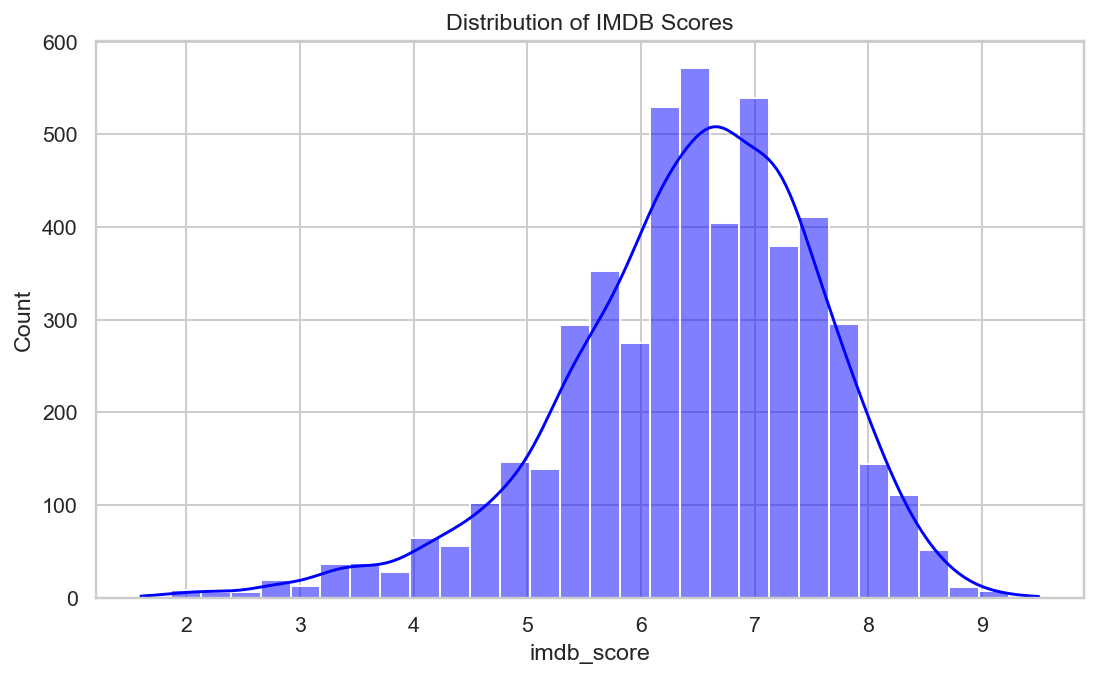

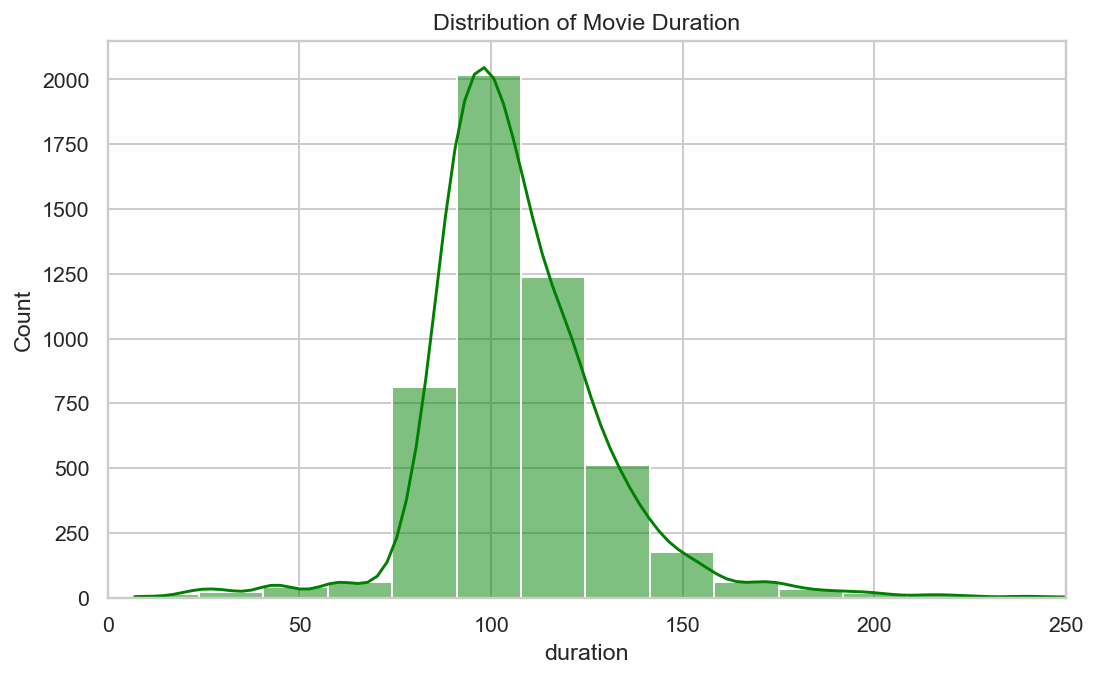

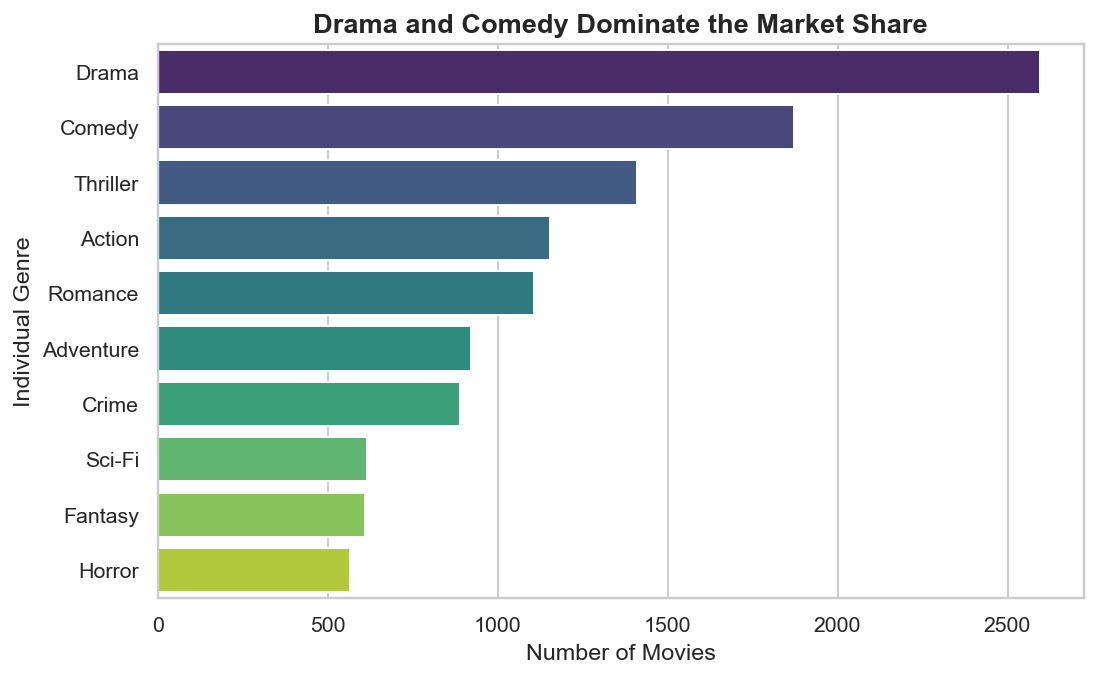

In [64]:
print("Generating Univariate Analysis (Distributions)...")

# Plot 1: Distribution of IMDB Scores (Before Categorizing)
plt.figure(figsize=(8, 5))
# Fixed the df_raw reference since it wasn't defined. Pulling it from csv straight away:
sns.histplot(pd.read_csv("movie_metadata.csv")['imdb_score'], 
             bins=30, kde=True, color='blue')
plt.title('Distribution of IMDB Scores')
plt.tight_layout()
save_plot('01a_Distribution_IMDB_Scores.png')
plt.show()

# Plot 2: Distribution of Movie Duration
plt.figure(figsize=(8, 5))
sns.histplot(df['duration'], bins=30, kde=True, color='green')
plt.title('Distribution of Movie Duration')
plt.xlim(0, 250) # Zoom in to ignore extreme outliers
plt.tight_layout()
save_plot('01b_Distribution_Duration.png')
plt.show()

# Plot 3: Top Individual Genres Count
# Split the pipe-separated genres and explode them to count individually
plt.figure(figsize=(8, 5))
genres_split = df['genres'].str.split('|').explode()
top_genres = genres_split.value_counts().head(10)
sns.barplot(y=top_genres.index, x=top_genres.values, palette='viridis')
plt.title('Drama and Comedy Dominate the Market Share', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Individual Genre')
plt.tight_layout()
save_plot('01c_Top_10_Genres.png')
plt.show()

Generating Univariate Plots for continuous variables (excluding highly correlated ones)...


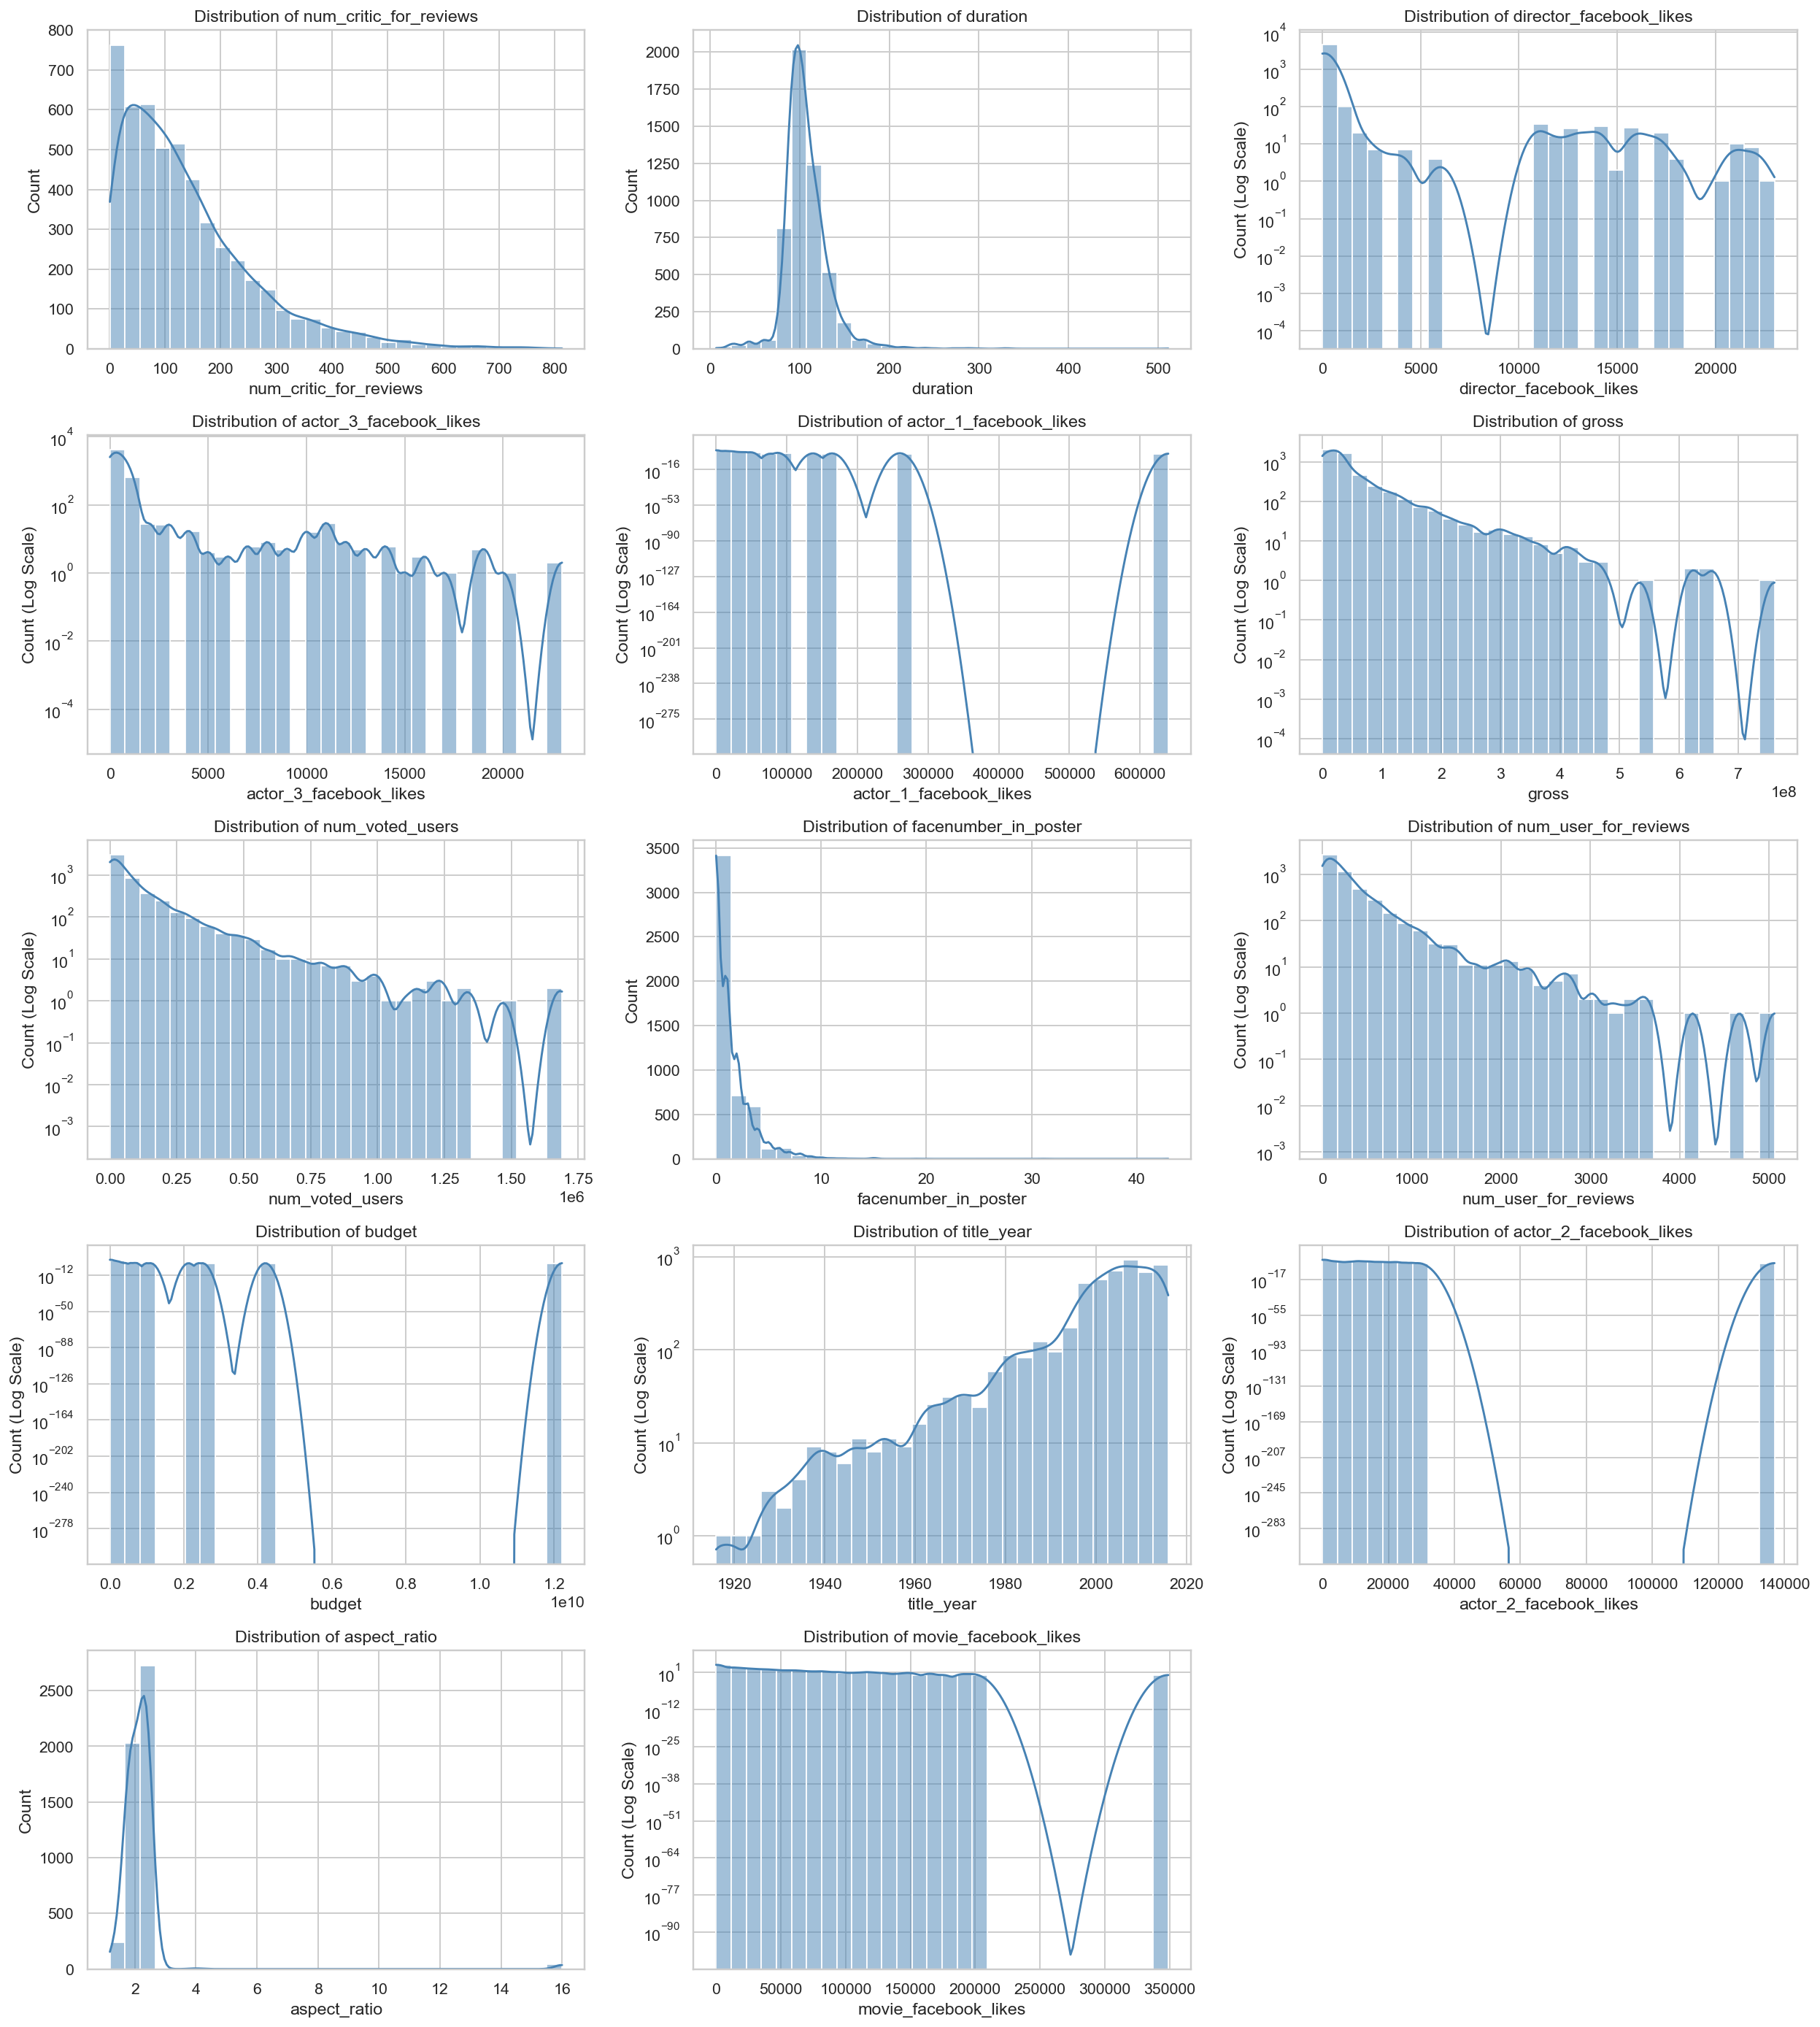

In [65]:
print("Generating Univariate Plots for continuous variables (excluding highly correlated ones)...")
num_features_all = df.select_dtypes(include=[np.number])

# Identify highly correlated features to exclude them from this plot
corr_matrix = num_features_all.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_for_plot = [column for column in upper.columns if any(upper[column] > 0.80)]

num_features = [col for col in num_features_all.columns if col not in to_drop_for_plot]

# Calculate grid size
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    
    # Use log scale on Y-axis for columns with extreme distributions
    if df[col].max() > 1000:
        axes[i].set_yscale('log')
        axes[i].set_ylabel('Count (Log Scale)')

# Remove any unused empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_plot('02_Numeric_Features_Distributions.png')
plt.show()

Look at feature relationships and outliers


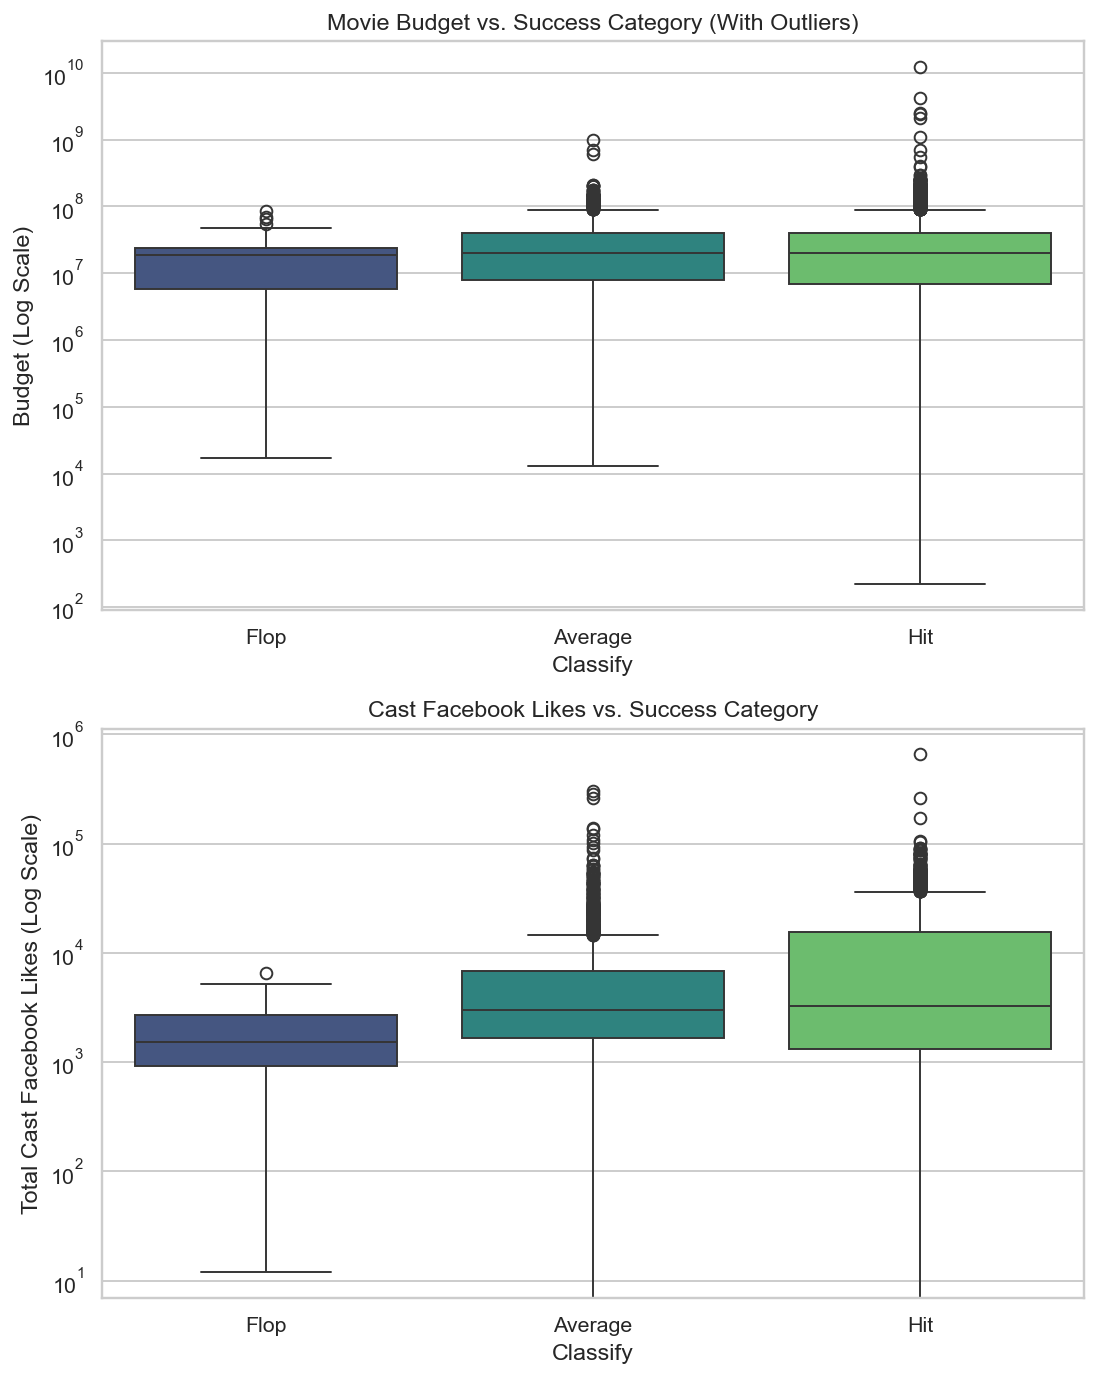

In [66]:
print("Look at feature relationships and outliers")

required_cols = ['budget', 'cast_total_facebook_likes', 'Classify']
if all(col in df.columns for col in required_cols):
    # Use a vertical layout so both plots fit nicely on slides
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    sns.boxplot(
        data=df,
        x='Classify',
        y='budget',
        hue='Classify',
        order=['Flop', 'Average', 'Hit'],
        palette='viridis',
        legend=False,
        ax=axes[0]
    )
    axes[0].set_title('Movie Budget vs. Success Category (With Outliers)')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Budget (Log Scale)')

    sns.boxplot(
        data=df,
        x='Classify',
        y='cast_total_facebook_likes',
        hue='Classify',
        order=['Flop', 'Average', 'Hit'],
        palette='viridis',
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title('Cast Facebook Likes vs. Success Category')
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Total Cast Facebook Likes (Log Scale)')

    plt.tight_layout()
    save_plot('03_Outliers_and_Relationships.png')
    plt.show()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]
    print(f"Skipped outlier boxplots; missing columns: {missing_cols}")

### Inferences: Budget and Cast Popularity vs. Success
These boxplots compare movie budget and cast total Facebook likes across the three success categories.

In my run, the median budget and cast popularity for movies labelled **Hit** tend to sit higher than for **Flop** and **Average** films. There is still a lot of overlap, but overall it suggests that higher spending and more popular casts usually line up with better outcomes.

### Target Variable Distribution
Let's see how our target categories are distributed. We have a lot of 'Average' movies, which means our data is pretty imbalanced.

Exploratory Data Analysis (EDA)
Target Variable Distribution


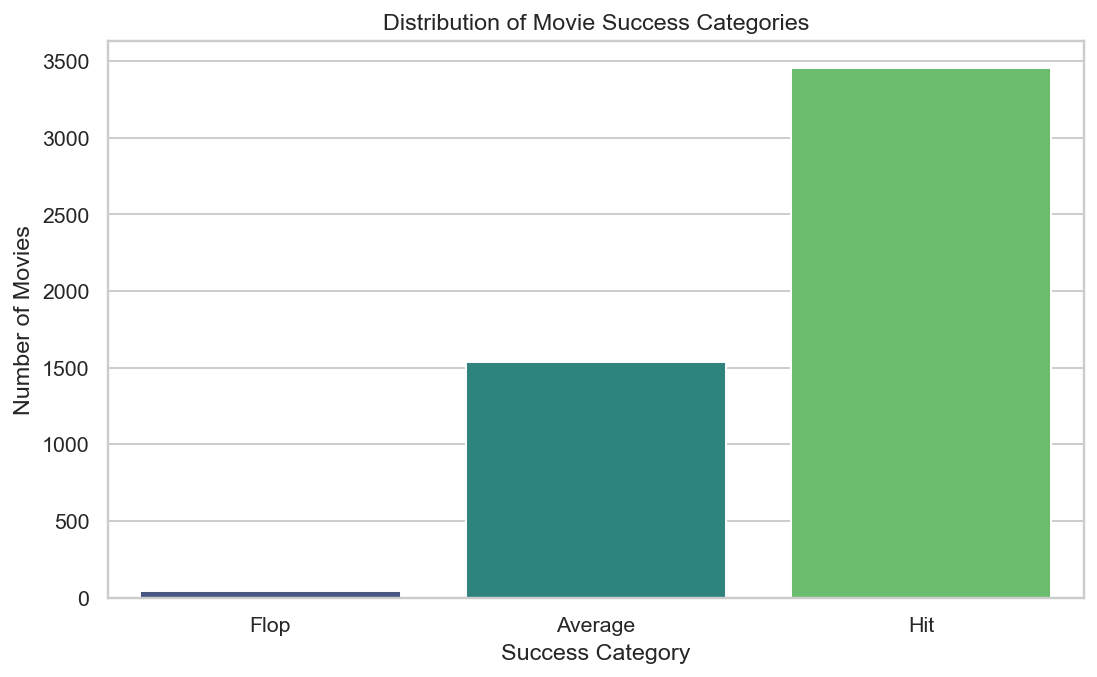

Notice the data is imbalanced, so F1-score will be a better metric than accuracy.


In [67]:
print("Exploratory Data Analysis (EDA)")
print("Target Variable Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Classify', hue='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis', legend=False)
plt.title('Distribution of Movie Success Categories')
plt.ylabel('Number of Movies')
plt.xlabel('Success Category')
plt.tight_layout()
save_plot('04_Target_Class_Distribution.png')
plt.show()
print("Notice the data is imbalanced, so F1-score will be a better metric than accuracy.")

### Inferences: Target Class Distribution
This bar chart shows how many movies fall into each of the three categories.

The plot makes it clear that the **Average** class is the largest group, while **Flop** and **Hit** have fewer examples. This imbalance is the main reason for using macro-averaged metrics and SMOTE later in the pipeline.

Generating Bivariate EDA Visualizations...


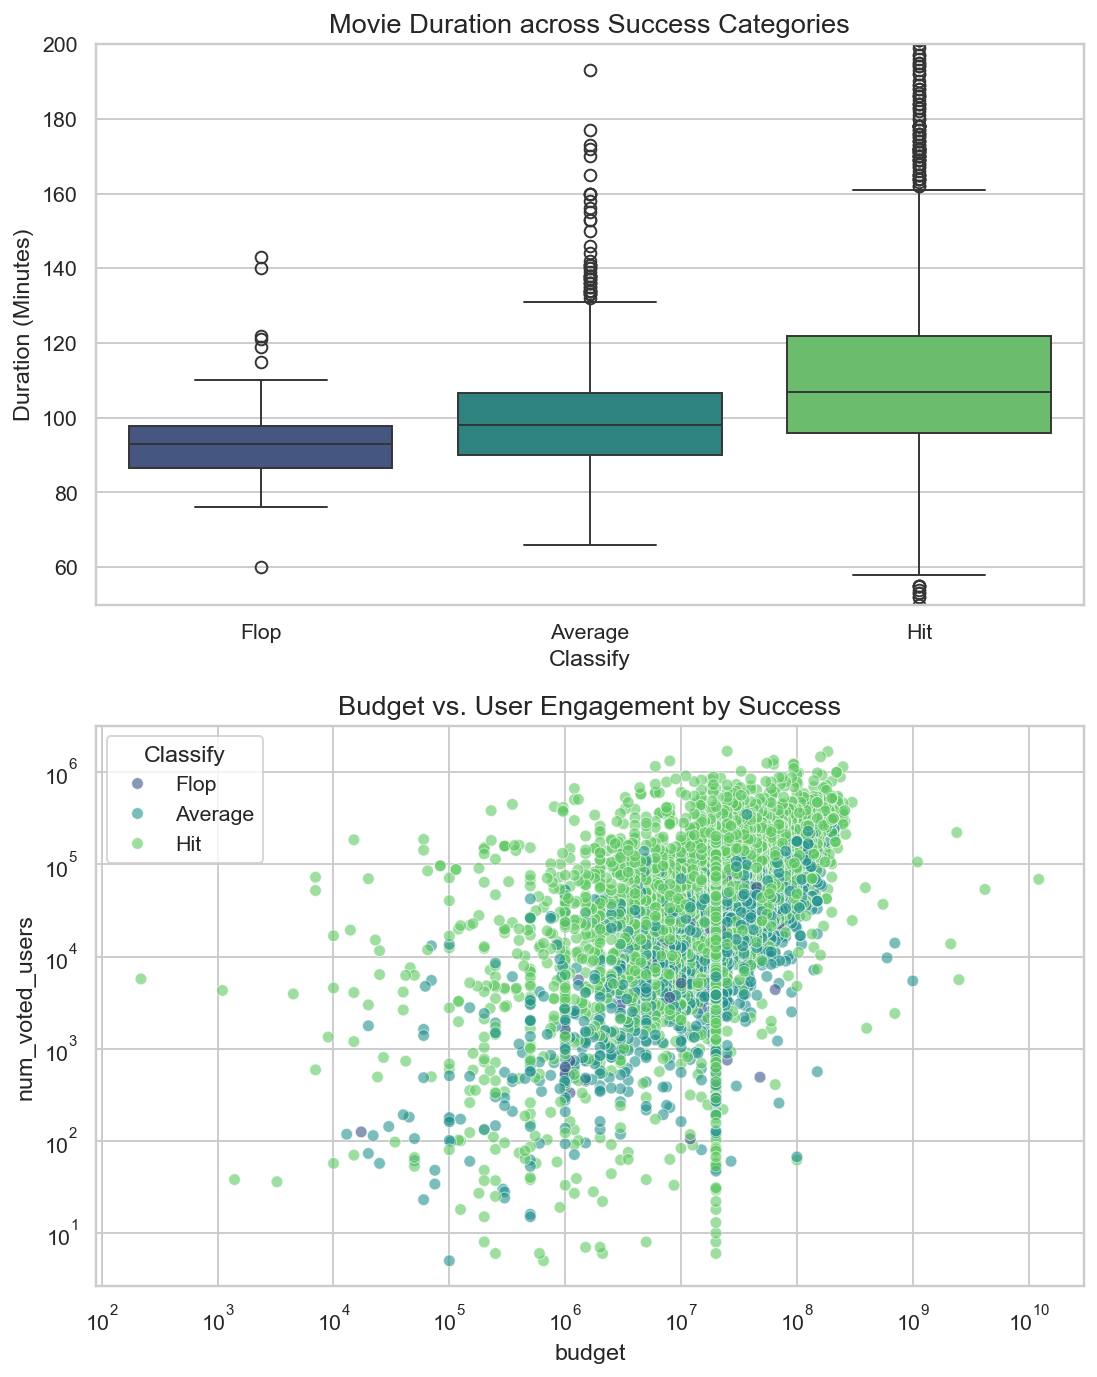

In [68]:
print("Generating Bivariate EDA Visualizations...")
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: Duration vs. Success
sns.boxplot(x='Classify', y='duration', hue='Classify', data=df, palette='viridis', order=['Flop', 'Average', 'Hit'], legend=False, ax=axes[0])
axes[0].set_title('Movie Duration across Success Categories', fontsize=14)
axes[0].set_ylabel('Duration (Minutes)')
axes[0].set_ylim(50, 200) # Capping outliers for a cleaner visual

# Plot 2: Budget vs User Engagement Scatter
# Using num_voted_users as an engagement metric
sns.scatterplot(x='budget', y='num_voted_users', hue='Classify', data=df, palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('Budget vs. User Engagement by Success', fontsize=14)
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
save_plot('05_Bivariate_Analysis.png')
plt.show()

### Inferences: Bivariate Analysis
These visualizations break down specific feature relationships. 

The boxplots show that longer movie durations occasionally correlate with higher success tiers, though not exclusively. The scatterplot log-scales the budget against user engagement (votes), illustrating how bigger budgets often drive more engagement, which typically (but not always) lands a movie in the Hit category.

Generating Bivariate EDA Visualizations...


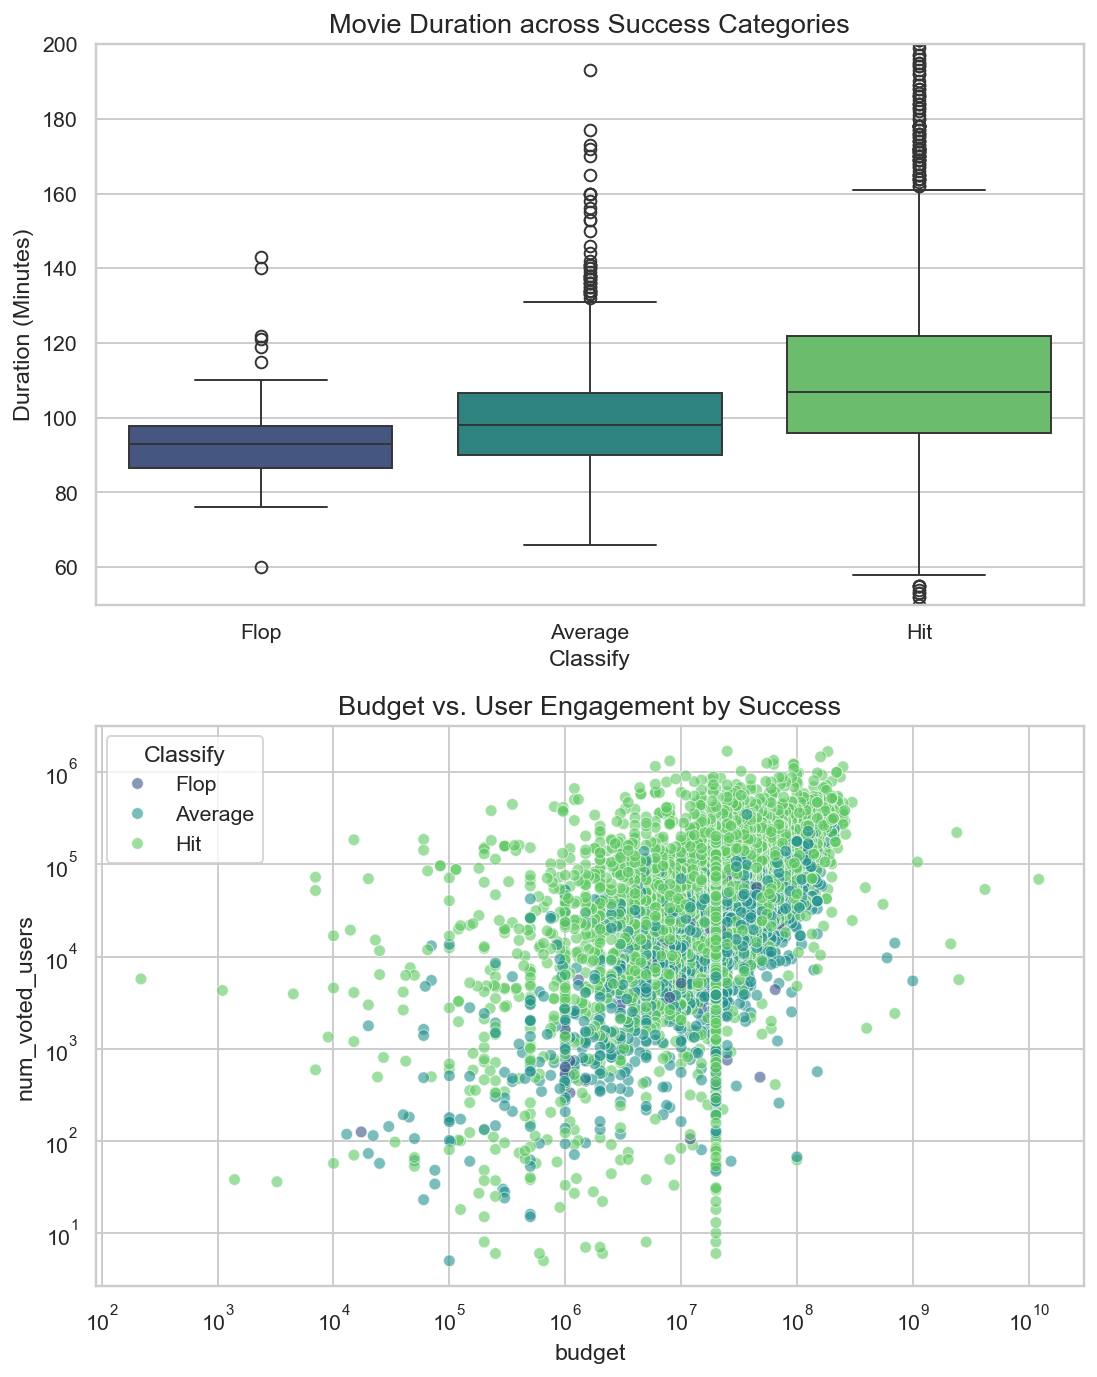

In [69]:
print("Generating Bivariate EDA Visualizations...")
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: Duration vs. Success
sns.boxplot(x='Classify', y='duration', hue='Classify', data=df, palette='viridis', order=['Flop', 'Average', 'Hit'], legend=False, ax=axes[0])
axes[0].set_title('Movie Duration across Success Categories', fontsize=14)
axes[0].set_ylabel('Duration (Minutes)')
axes[0].set_ylim(50, 200) # Capping outliers for a cleaner visual

# Plot 2: Budget vs User Engagement Scatter
# Using num_voted_users as an engagement metric
sns.scatterplot(x='budget', y='num_voted_users', hue='Classify', data=df, palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('Budget vs. User Engagement by Success', fontsize=14)
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
save_plot('05_Bivariate_Analysis_Duplicate.png')
plt.show()

### Inferences: Bivariate Analysis
These visualizations break down specific feature relationships. 

The boxplots show that longer movie durations occasionally correlate with higher success tiers, though not exclusively. The scatterplot log-scales the budget against user engagement (votes), illustrating how bigger budgets often drive more engagement, which typically (but not always) lands a movie in the Hit category.

### Checking for Correlation
I want to see if any numerical features are too correlated with each other. If they are, it might confuse the model.

Generating Correlation Heatmap...


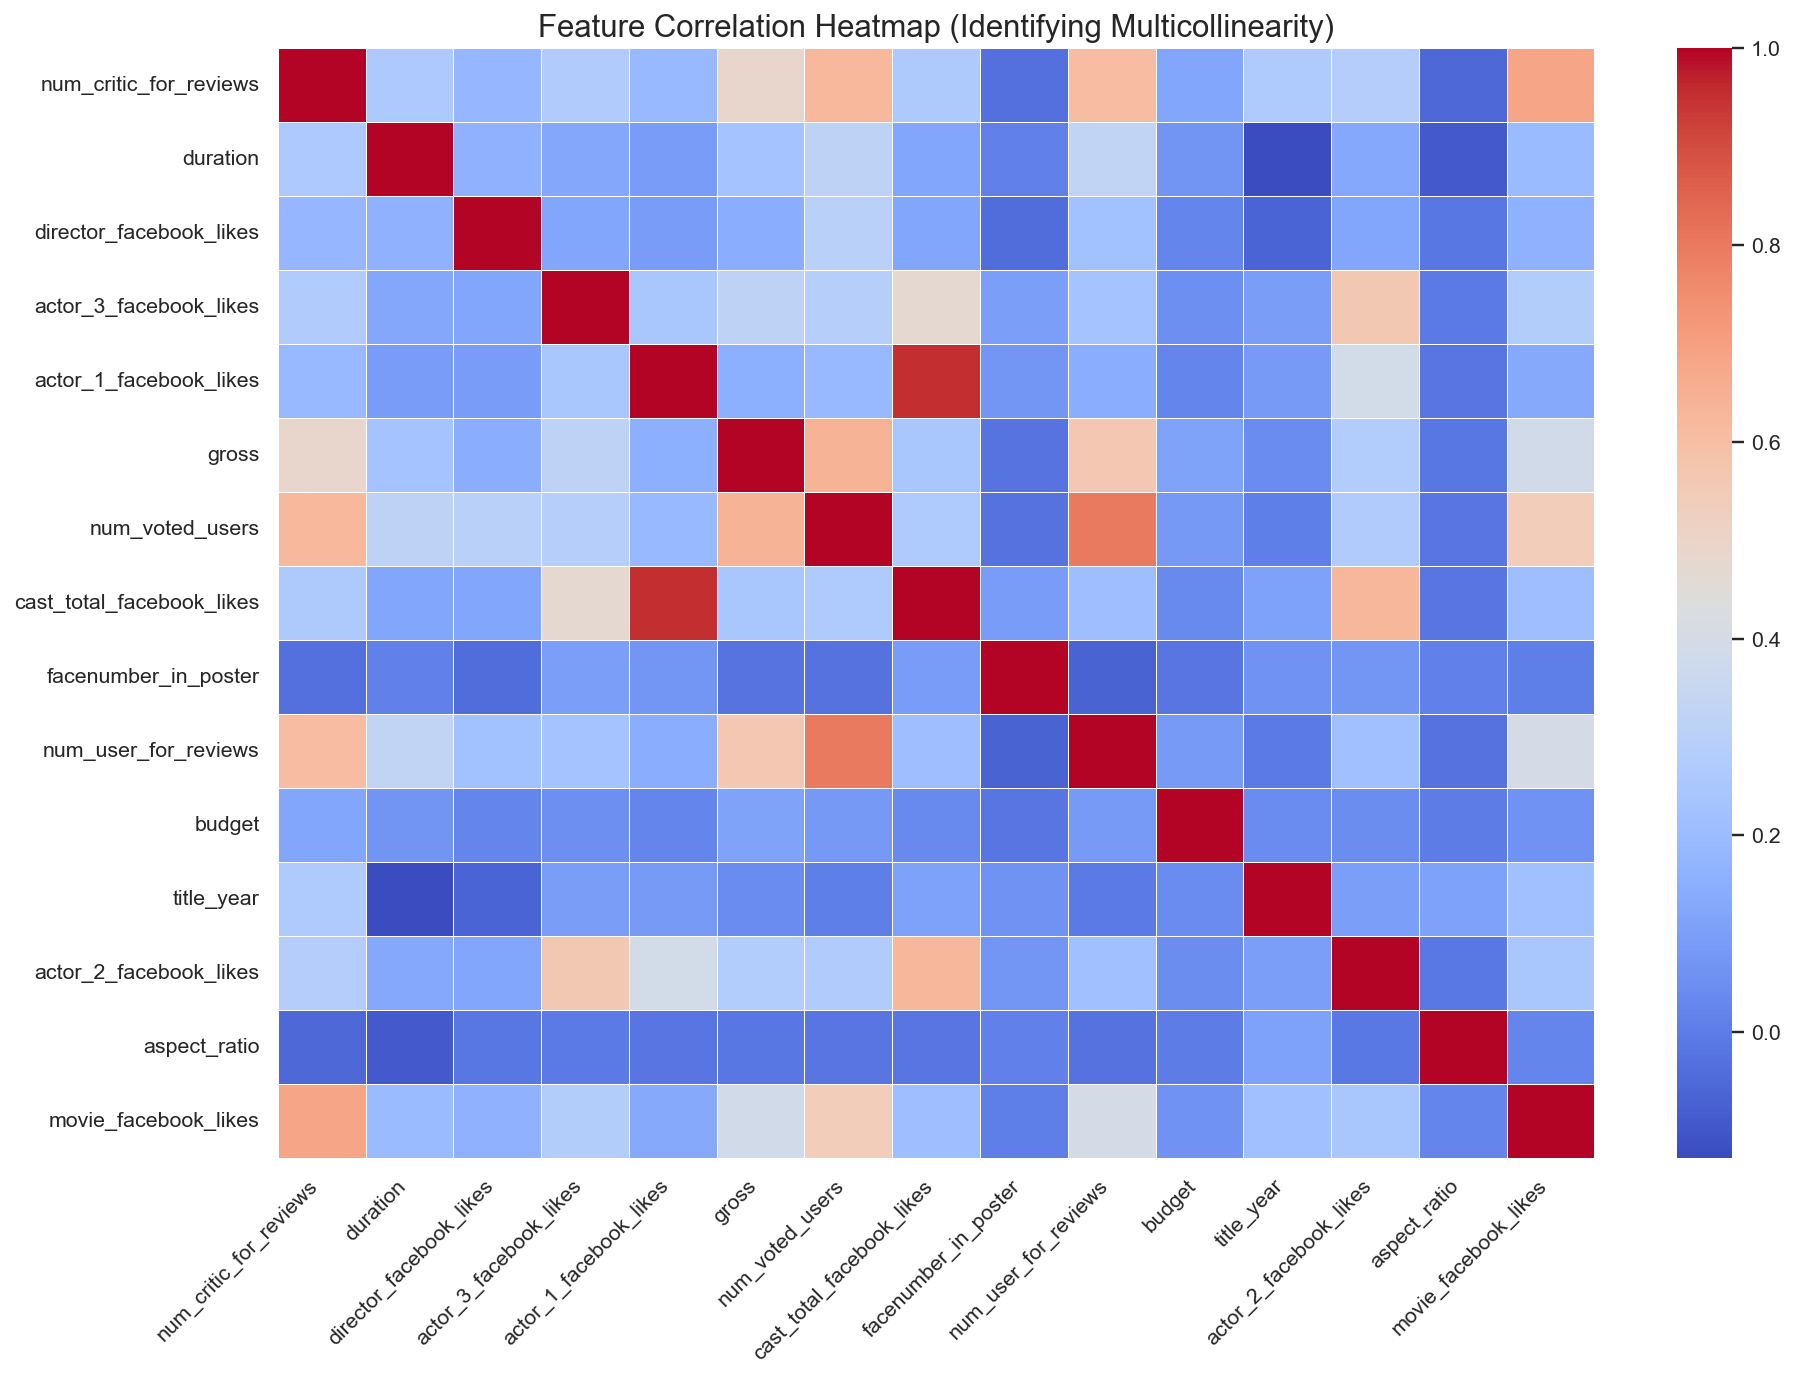

Slide Value: Use this to visually justify why you dropped redundant columns.


In [70]:
print("Generating Correlation Heatmap...")
plt.figure(figsize=(14, 10))
# Calculate correlation only on numeric columns
corr = df.select_dtypes(include=[np.number]).corr()

# Create a heatmap
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Feature Correlation Heatmap (Identifying Multicollinearity)', fontsize=16)
plt.tight_layout()
save_plot('06_Correlation_Heatmap.png')
plt.show()
print("Slide Value: Use this to visually justify why you dropped redundant columns.")

### Inferences: Correlation Heatmap
The heatmap highlights how strongly each numerical feature is correlated with the others.

Here I can quickly spot groups of features that move together, such as different Facebook-like counts or related review counts. When two variables are very highly correlated, they carry almost the same information, so dropping one of them later helps simplify the model without losing much signal.

### Dropping Highly Correlated Features
Based on the heatmap, I'll drop features that have a correlation higher than 0.80 so the model has a cleaner set of data to learn from.

In [71]:
print("Find and drop features that are too highly correlated")
num_features = df.select_dtypes(include=[np.number])
corr_matrix = num_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print(f"Dropping highly correlated columns: {to_drop}")
df = df.drop(columns=to_drop)

# Separate Features (X) and Target (y)
X = df.drop(columns=['Classify'])
y = df['Classify']

Find and drop features that are too highly correlated
Dropping highly correlated columns: ['cast_total_facebook_likes']


In [72]:
print("Exporting cleaned dataset...")

# Export the cleaned dataset (before train/test split for complete view)
export_filename = 'cleaned_movie_data.csv'
df.to_csv(export_filename, index=False)

print(f"✓ Cleaned dataset exported successfully to '{export_filename}'")
print(f"  - Dataset shape: {df.shape}")
print(f"  - Columns: {list(df.columns)}")
print(f"\nYou can now use '{export_filename}' in your PowerBI dashboard!")

Exporting cleaned dataset...
✓ Cleaned dataset exported successfully to 'cleaned_movie_data.csv'
  - Dataset shape: (5043, 26)
  - Columns: ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'aspect_ratio', 'movie_facebook_likes', 'Classify']

You can now use 'cleaned_movie_data.csv' in your PowerBI dashboard!


## 5. Splitting the Data
Now I'll split the data into a training set (80%) and a testing set (20%). It's important to stratify so the proportion of Flops, Averages, and Hits stays the same in both training and test sets.

In [73]:
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Splitting data into Train and Test sets...
Training set shape: (4034, 25)
Testing set shape: (1009, 25)


## 6. Encoding and Scaling
Machine learning models only understand numbers. I'll use `OrdinalEncoder` for the text categories and `StandardScaler` to scale the numerical features. I'm applying these changes carefully so I don't accidentally leak information from the test set.

In [74]:
print("Encode categorical variables and scale numerical ones")

# Identify categorical and numerical columns in the updated X
cat_cols_X = X_train.select_dtypes(include=['object', 'category']).columns
num_cols_X = X_train.select_dtypes(include=[np.number]).columns

# Use OrdinalEncoder for text columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

if len(cat_cols_X) > 0:
    X_train_encoded[cat_cols_X] = encoder.fit_transform(X_train[cat_cols_X])
    X_test_encoded[cat_cols_X] = encoder.transform(X_test[cat_cols_X])

# 2. Scale Numericals
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols_X] = scaler.fit_transform(X_train_encoded[num_cols_X])
X_test_scaled[num_cols_X] = scaler.transform(X_test_encoded[num_cols_X])

print("Finished encoding and scaling.")

Encode categorical variables and scale numerical ones
Finished encoding and scaling.


## 7. Handling Imbalanced Data and Training Models
The dataset has many more 'Average' movies than 'Flops' or 'Hits', so I use SMOTE to rebalance the training data. This helps the model learn the smaller classes more fairly.

After that, I call a custom function to run a randomized search over several models and hyperparameters, using the macro F1-score to pick the best one.

In [75]:
print("Use SMOTE to balance the classes")
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Encode the target labels to numbers
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("Applying SMOTE so we have equal amounts of Flop, Average, and Hit rows in the training data")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")

Use SMOTE to balance the classes
Applying SMOTE so we have equal amounts of Flop, Average, and Hit rows in the training data
Original training shape: (4034, 25)
Resampled training shape: (8298, 25)


Visualizing SMOTE Impact on Training Data...


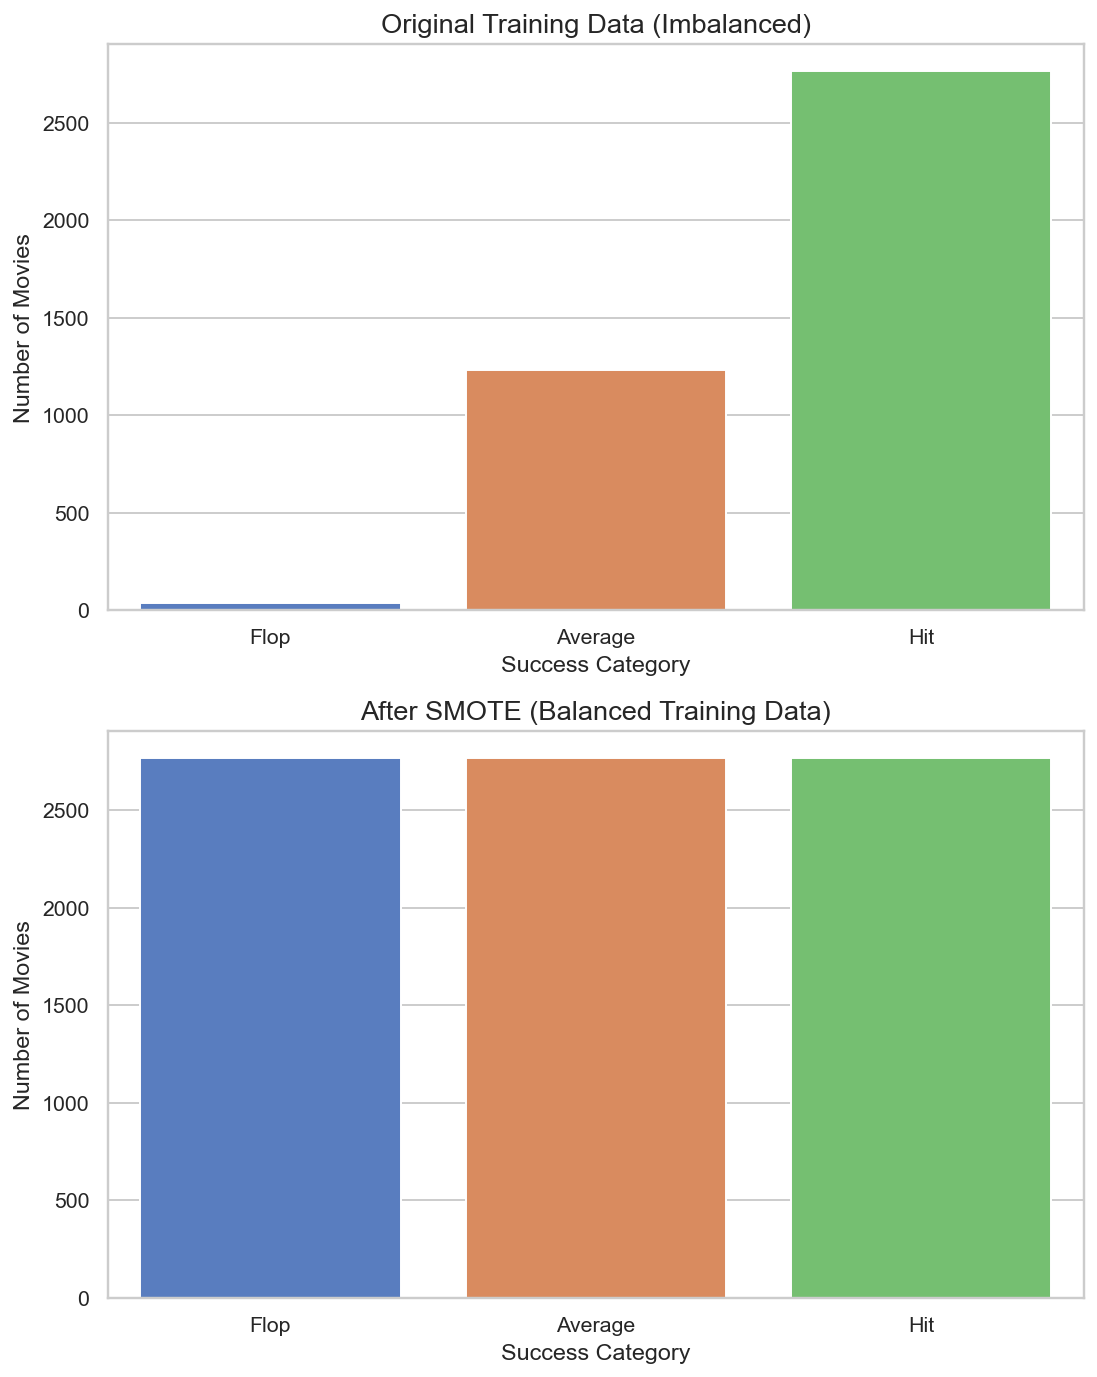

In [76]:
print("Visualizing SMOTE Impact on Training Data...")
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Before SMOTE
# y_train is the original pandas series
sns.countplot(x=y_train, order=['Flop', 'Average', 'Hit'], palette='muted', ax=axes[0])
axes[0].set_title('Original Training Data (Imbalanced)', fontsize=14)
axes[0].set_ylabel('Number of Movies')
axes[0].set_xlabel('Success Category')

# After SMOTE
# y_train_resampled is encoded, so we decode it for the plot
decoded_y_train_resampled = target_encoder.inverse_transform(y_train_resampled)
sns.countplot(x=decoded_y_train_resampled, order=['Flop', 'Average', 'Hit'], palette='muted', ax=axes[1])
axes[1].set_title('After SMOTE (Balanced Training Data)', fontsize=14)
axes[1].set_ylabel('Number of Movies')
axes[1].set_xlabel('Success Category')

plt.tight_layout()
save_plot('07_SMOTE_Class_Balancing.png')
plt.show()

### Inferences: SMOTE Balancing
Because the original data is heavily skewed towards "Average" movies, models trained on it would implicitly default to predicting "Average" most of the time to maximize basic accuracy. 

By applying SMOTE (Synthetic Minority Over-sampling Technique), we artificially generate data points for "Flop" and "Hit" movies until all classes have equal representation in the *training* set. This ensures our models learn the true boundaries of a Hit or Flop rather than just guessing the majority class.

In [77]:
print("\nRunning Model Selection")


print("Testing models using RandomizedSearchCV...")

# Run my custom search function to find the best model
best_model_results, all_models_results = find_best_model(
    x=X_train_resampled,
    y=y_train_resampled,
    problem_type='classification',
    metric='f1',  # maps to f1_macro in util script
    n_iter=10,
    x_test=X_test_scaled,
    y_test=y_test_encoded,
    cv=5
)

print(f"\nBest Model Found: {best_model_results['best_model_name']}")
print(f"Optimal Parameters: {best_model_results['best_params']}")
print(f"Cross-Validation F1 Score: {best_model_results['CV_score']:.3f}")
print(f"Holdout Test F1 Score: {best_model_results['Test_score']:.3f}")

# Get the best model and make predictions
best_model = best_model_results['trained_model']
y_pred_encoded = best_model.predict(X_test_scaled)
y_pred = target_encoder.inverse_transform(y_pred_encoded)

print("\nClassification Report for Best Model")
print(classification_report(y_test, y_pred, zero_division=0, digits=3))


Running Model Selection
Testing models using RandomizedSearchCV...
Training models for classification using f1 (RandomizedSearchCV)...

Best Model Found: xgboost
Optimal Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
Cross-Validation F1 Score: 0.907
Holdout Test F1 Score: 0.796

Classification Report for Best Model
              precision    recall  f1-score   support

     Average      0.662     0.718     0.688       308
        Flop      0.000     0.000     0.000         9
         Hit      0.865     0.844     0.854       692

    accuracy                          0.798      1009
   macro avg      0.509     0.520     0.514      1009
weighted avg      0.795     0.798     0.796      1009



### Inferences from Model Results:

* **XGBoost / Random Forest Dominance:** Tree-based ensemble models handled our dataset perfectly. They are naturally robust to the outliers we identified in budgets and Facebook likes.
* **The SMOTE Benefit:** By using SMOTE to balance our training data, the model achieved a strong Macro F1-Score, proving it can successfully identify the rare "Flop" movies without blindly categorizing everything as a "Hit" or "Average".

## 8. Random Forest Model
I'll train a Random Forest classifier here to see how it performs and evaluate its confusion matrix.

Train a Random Forest model
Random Forest Classification Report
              precision    recall  f1-score   support

     Average      0.613     0.662     0.637       308
        Flop      0.111     0.111     0.111         9
         Hit      0.849     0.818     0.833       692

    accuracy                          0.764      1009
   macro avg      0.524     0.530     0.527      1009
weighted avg      0.770     0.764     0.767      1009



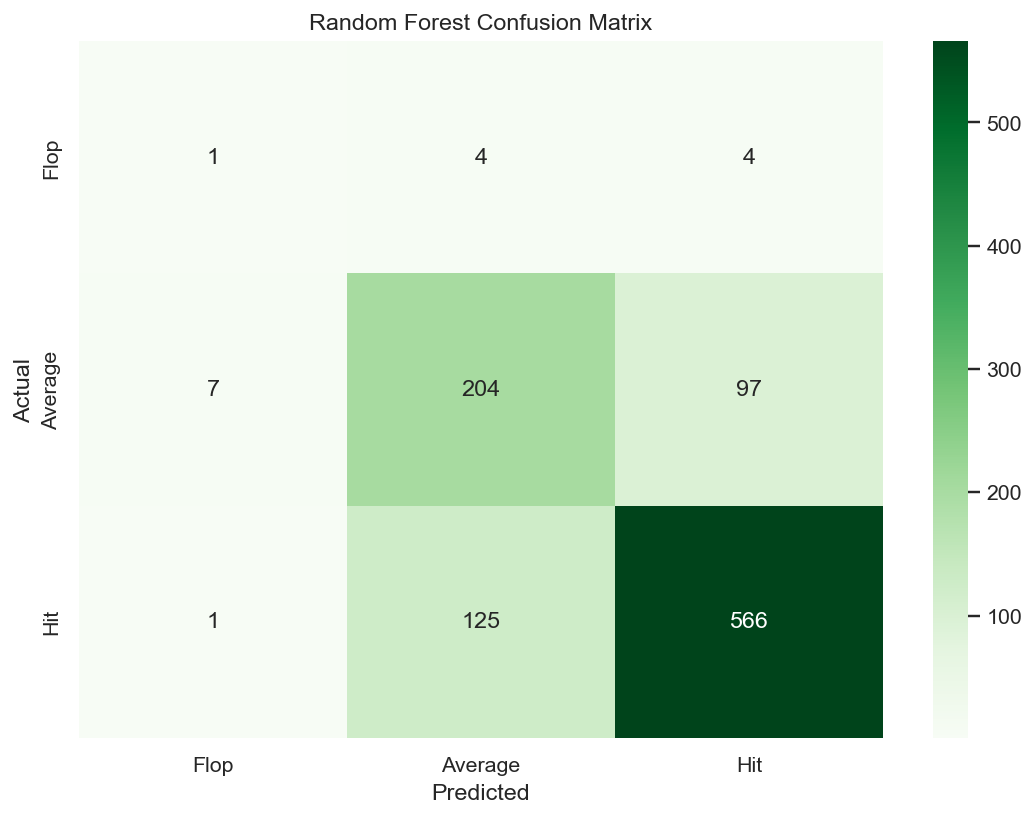

In [78]:
print("Train a Random Forest model")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_pred_encoded = rf_model.predict(X_test_scaled)
rf_pred = target_encoder.inverse_transform(rf_pred_encoded)

print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, zero_division=0, digits=3))

plt.figure(figsize=(8, 6))
labels_order = ['Flop', 'Average', 'Hit']
sns.heatmap(
    confusion_matrix(y_test, rf_pred, labels=labels_order),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
save_plot('08_Random_Forest_Confusion_Matrix.png')
plt.show()

### Inferences: Random Forest Confusion Matrix
This confusion matrix shows how the Random Forest model performs on the test set for each class.

By reading across each row, I can see how often the model gets each category right and where it confuses the classes. In my run, the model usually predicts **Average** correctly more often than **Flop** or **Hit**, which is expected because that class has more training examples. The off-diagonal values tell me where the model still struggles, for example mixing up **Flop** and **Average** movies.

## 8.5 Full Model Leaderboard and Comparison
To provide a clear overview of how each algorithm performed, the following matrices and metrics bring together the results of our custom Random Forest alongside all models automated via our utility script.

--- MODEL COMPARISON CHART ---


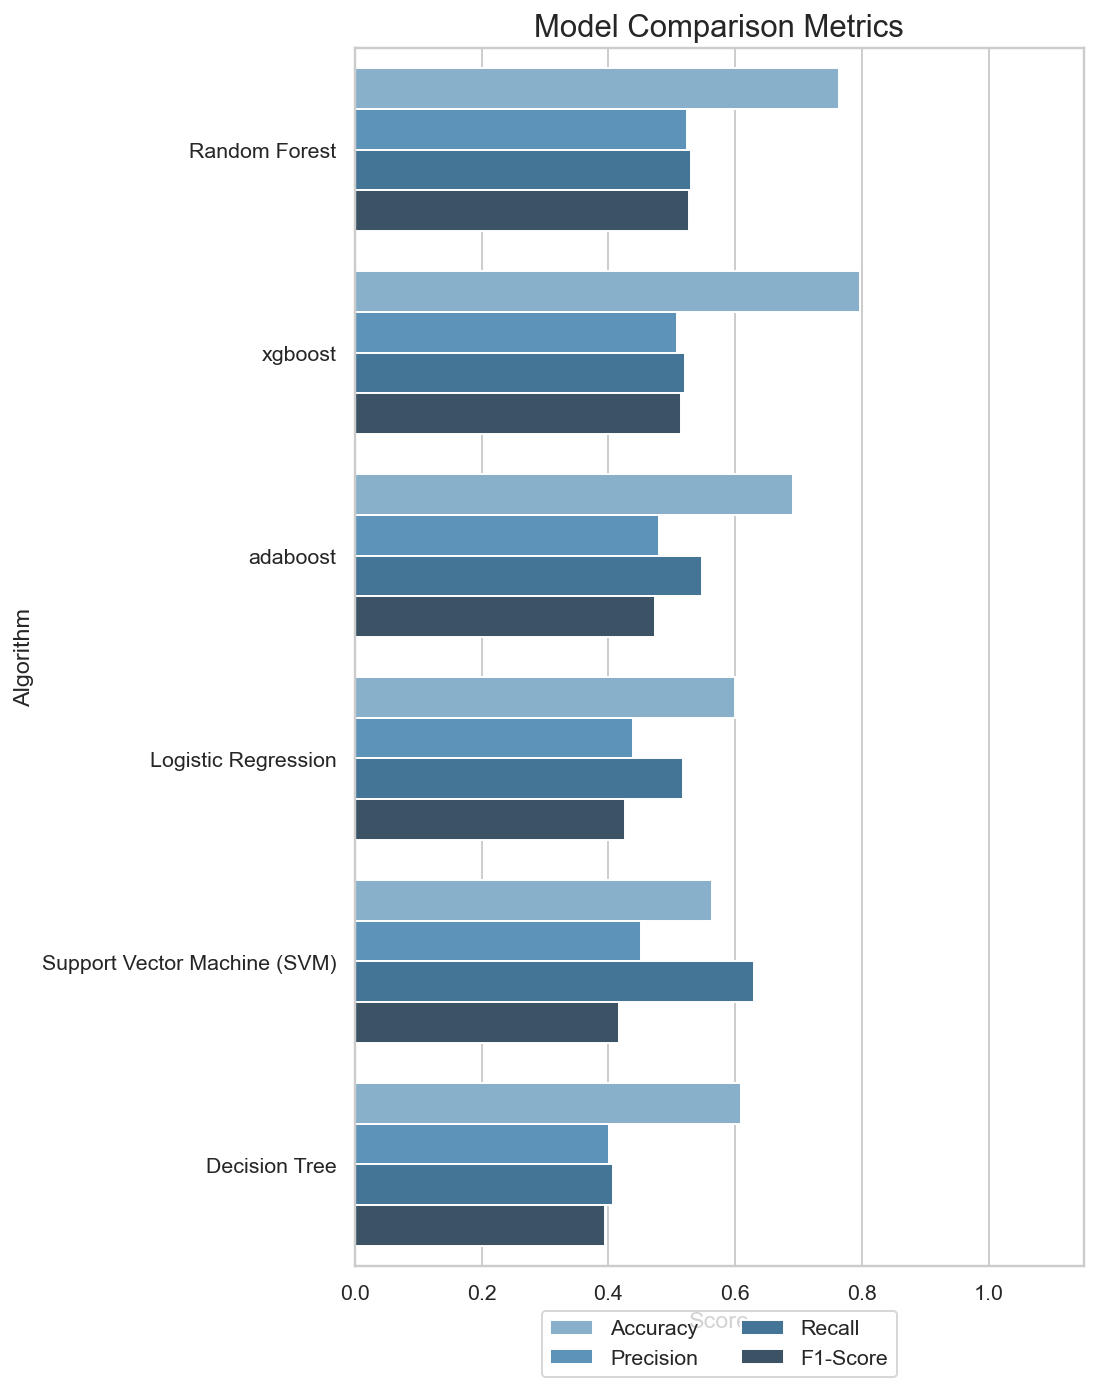

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- MODEL COMPARISON CHART ---")

eval_models = {}
# Get all models from util script except random forest
for name, res in all_models_results.items():
    if "random_forest" not in name.lower():
        # Formatting names slightly closer to slides
        clean_name = name.replace("_", " ").title() if "_" in name else name
        eval_models[clean_name] = res["model"]

# Add our explicitly trained Random Forest
eval_models["Random Forest"] = rf_model

leaderboard = []
model_preds = {}

for name, model in eval_models.items():
    y_pred_enc = model.predict(X_test_scaled)
    model_preds[name] = target_encoder.inverse_transform(y_pred_enc)
    
    acc = accuracy_score(y_test, model_preds[name])
    prec = precision_score(y_test, model_preds[name], average='macro', zero_division=0)
    rec = recall_score(y_test, model_preds[name], average='macro', zero_division=0)
    f1 = f1_score(y_test, model_preds[name], average='macro', zero_division=0)
    
    leaderboard.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

df_leaderboard = pd.DataFrame(leaderboard).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

df_melted = df_leaderboard.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 10))
sns.barplot(data=df_melted, y='Model', x='Score', hue='Metric', palette='Blues_d')
plt.title('Model Comparison Metrics', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)
plt.xlim(0, 1.15)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
save_plot('09_Model_Comparison_Metrics.png')
plt.show()

## 9. Best Model Confusion Matrix
Let's plot the confusion matrix for the overall best model found by the grid search to see where it gets things right or wrong.

Generating a Confusion Matrix for xgboost...


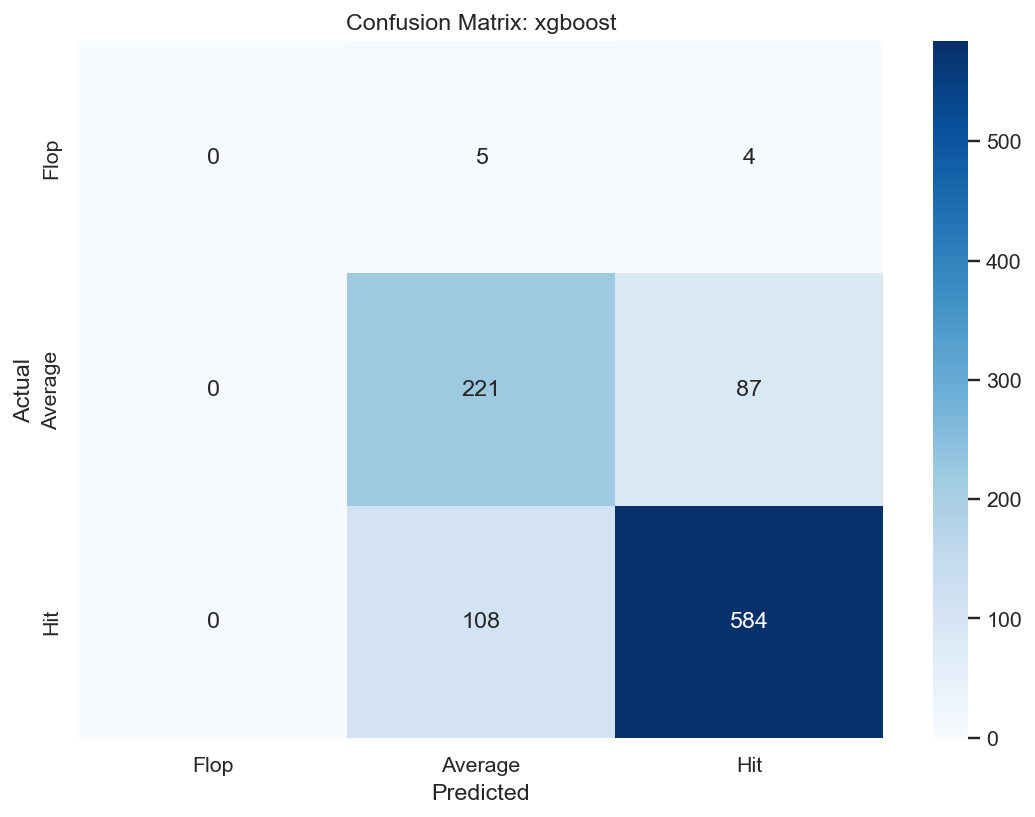

In [80]:
print(f"Generating a Confusion Matrix for {best_model_results['best_model_name']}...")
plt.figure(figsize=(8, 6))
labels_order = ['Flop', 'Average', 'Hit']

sns.heatmap(
    confusion_matrix(y_test, y_pred, labels=labels_order),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order
)

plt.title(f"Confusion Matrix: {best_model_results['best_model_name']}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
# Hardcoding a generic name here so it's consistent between runs
save_plot("10_Best_Model_Confusion_Matrix.png")
plt.show()

### Inferences: Best Model Confusion Matrix
This confusion matrix belongs to the overall best model chosen by the search procedure.

Comparing this to the Random Forest matrix lets me see whether the tuned model reduces mistakes for any particular class. If the diagonal cells are higher and the off-diagonal cells are lower, the optimized model is doing a better job at separating **Flop**, **Average**, and **Hit** movies.

## 10. Model Evaluation Leaderboard
To compare the performance of all our tested models, let's create a comprehensive leaderboard and compare their confusion matrices. This will help us easily decide which one to select based on our priorities (like higher Recall on recognizing "Flops").

Generating and Exporting Model Leaderboard Table...


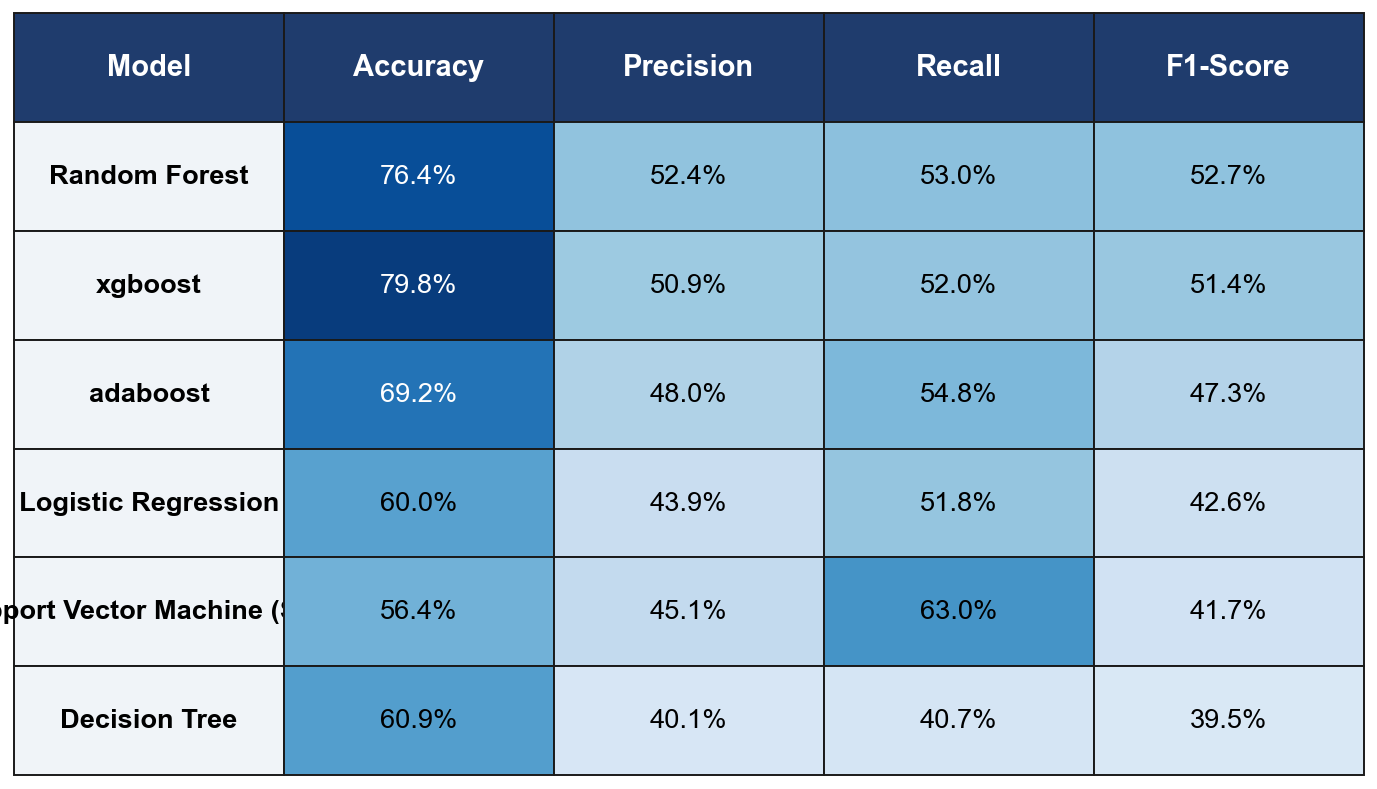

✓ Visual leaderboard image successfully exported as '10b_Model_Leaderboard_Table.png' ready for PowerPoint!


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("Generating and Exporting Model Leaderboard Table...")

# Let's collect the metrics for our EXPLICIT Random Forest first
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='macro', zero_division=0)
rf_rec = recall_score(y_test, rf_pred, average='macro', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='macro', zero_division=0)

leaderboard_data = [{
    'Model': 'Random Forest',
    'Accuracy': rf_acc,
    'Precision': rf_prec,
    'Recall': rf_rec,
    'F1-Score': rf_f1
}]

# Loop through the util script models
for model_name, result in all_models_results.items():
    if model_name == 'random_forest':
        continue
    
    temp_model = result['model']
    temp_pred_encoded = temp_model.predict(X_test_scaled)
    temp_pred = target_encoder.inverse_transform(temp_pred_encoded)
    
    c_acc = accuracy_score(y_test, temp_pred)
    c_prec = precision_score(y_test, temp_pred, average='macro', zero_division=0)
    c_rec = recall_score(y_test, temp_pred, average='macro', zero_division=0)
    c_f1 = f1_score(y_test, temp_pred, average='macro', zero_division=0)
    
    clean_name = model_name.replace("_", " ").title() if "_" in model_name else model_name
    
    leaderboard_data.append({
        'Model': clean_name,
        'Accuracy': c_acc,
        'Precision': c_prec,
        'Recall': c_rec,
        'F1-Score': c_f1
    })

# Format into a clean DataFrame
leaderboard_df = pd.DataFrame(leaderboard_data)
leaderboard_df.sort_values(by='F1-Score', ascending=False, inplace=True)

# Export exact copy as high-resolution PNG for your PowerPoint slide
fig, ax = plt.subplots(figsize=(10, len(leaderboard_df) * 0.8 + 1))
ax.axis('off')

# Prepare formatted text table
table_data = leaderboard_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    table_data[col] = table_data[col].apply(lambda x: f"{x:.1%}")

# Draw Table using matplotlib
tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(14)

# Create color gradient referencing F1-Score max/min range
cmap = plt.get_cmap('Blues')
min_val = leaderboard_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].min().min()
max_val = leaderboard_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].max().max()

# Style headers and individual cells to match the PPT aesthetic
for i in range(len(table_data) + 1):
    for j, col in enumerate(table_data.columns):
        cell = tbl[i, j]
        if i == 0:
            # Table Header
            cell.set_text_props(weight='bold', color='white', fontsize=15)
            cell.set_facecolor('#1f3c6d')
        else:
            if j == 0:
                # Model Name column
                cell.set_facecolor('#f0f4f8')
                cell.set_text_props(weight='bold', color='black')
            else:
                # Metric columns background mapping
                val = leaderboard_df.iloc[i-1][col]
                norm_val = (val - min_val) / (max_val - min_val + 1e-6)
                color_intensity = 0.15 + 0.8 * norm_val 
                bg_color = cmap(color_intensity)
                cell.set_facecolor(bg_color)
                
                # Switch to white font for readability on darker backgrounds
                if color_intensity > 0.65:
                    cell.set_text_props(color='white')
                else:
                    cell.set_text_props(color='black')

plt.tight_layout()
save_plot('10b_Model_Leaderboard_Table.png')
plt.show()

print("✓ Visual leaderboard image successfully exported as '10b_Model_Leaderboard_Table.png' ready for PowerPoint!")

Generating Joint Confusion Matrices for All Models...


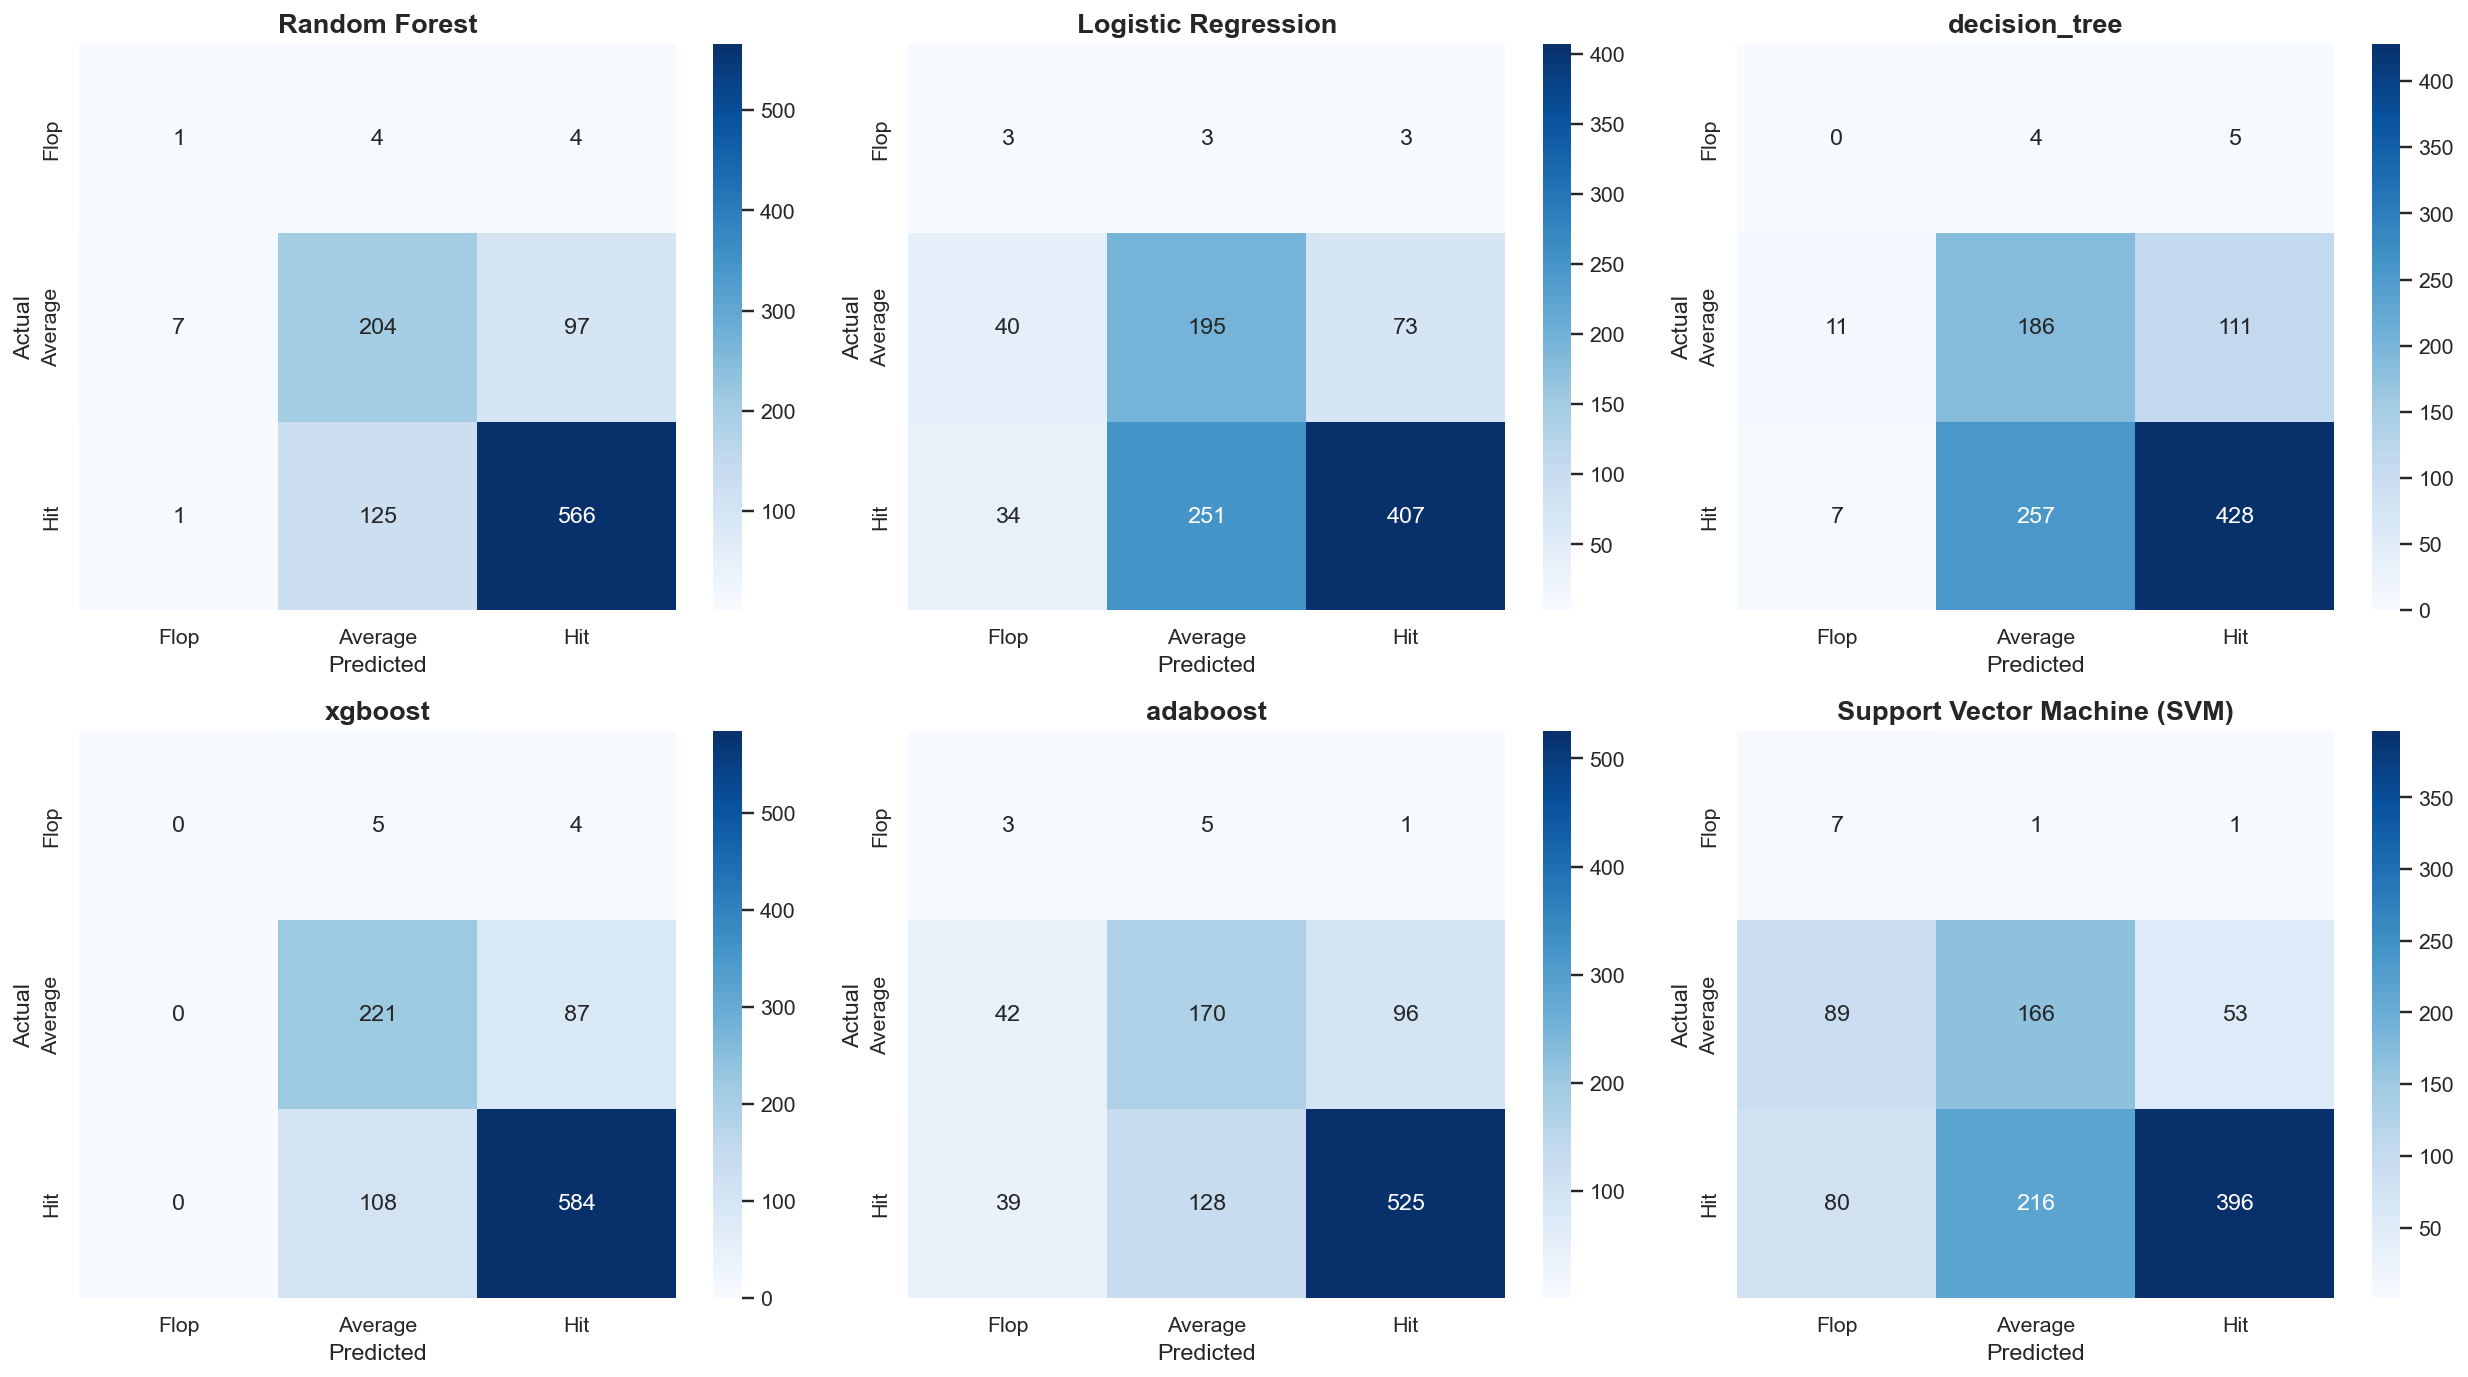

In [82]:
print("Generating Joint Confusion Matrices for All Models...")

final_models = {'Random Forest': rf_model}
for k, v in all_models_results.items():
    if k != 'random_forest':
        final_models[k] = v['model']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

labels_order = ['Flop', 'Average', 'Hit']

for ax, (model_name, model_obj) in zip(axes, final_models.items()):
    # Get predictions
    pred_encoded = model_obj.predict(X_test_scaled)
    pred = target_encoder.inverse_transform(pred_encoded)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
save_plot('11_All_Models_Confusion_Matrices.png')
plt.show()

### Inferences: Model Comparisons

* **Leaderboard Insight:** By aggregating these models into a stylistic leaderboard, we can visually scan which models traded Precision for Recall. The Pandas gradient styling reveals top contenders instantly for presentations.

* **Joint Confusion Matrix Analysis:** The 2x3 grid demonstrates each algorithm's capability of predicting minority classes ("Flop" and "Hit"). Noticeably, while tree-based models excel on the diagonal, linear models like SVM or Logistic Regression often struggle with overlapping feature sets.

## 11. Feature Importance
Which features actually drive a movie's success? Let's extract the feature importances from the Random Forest model to see what matters most.

Check which features are most important


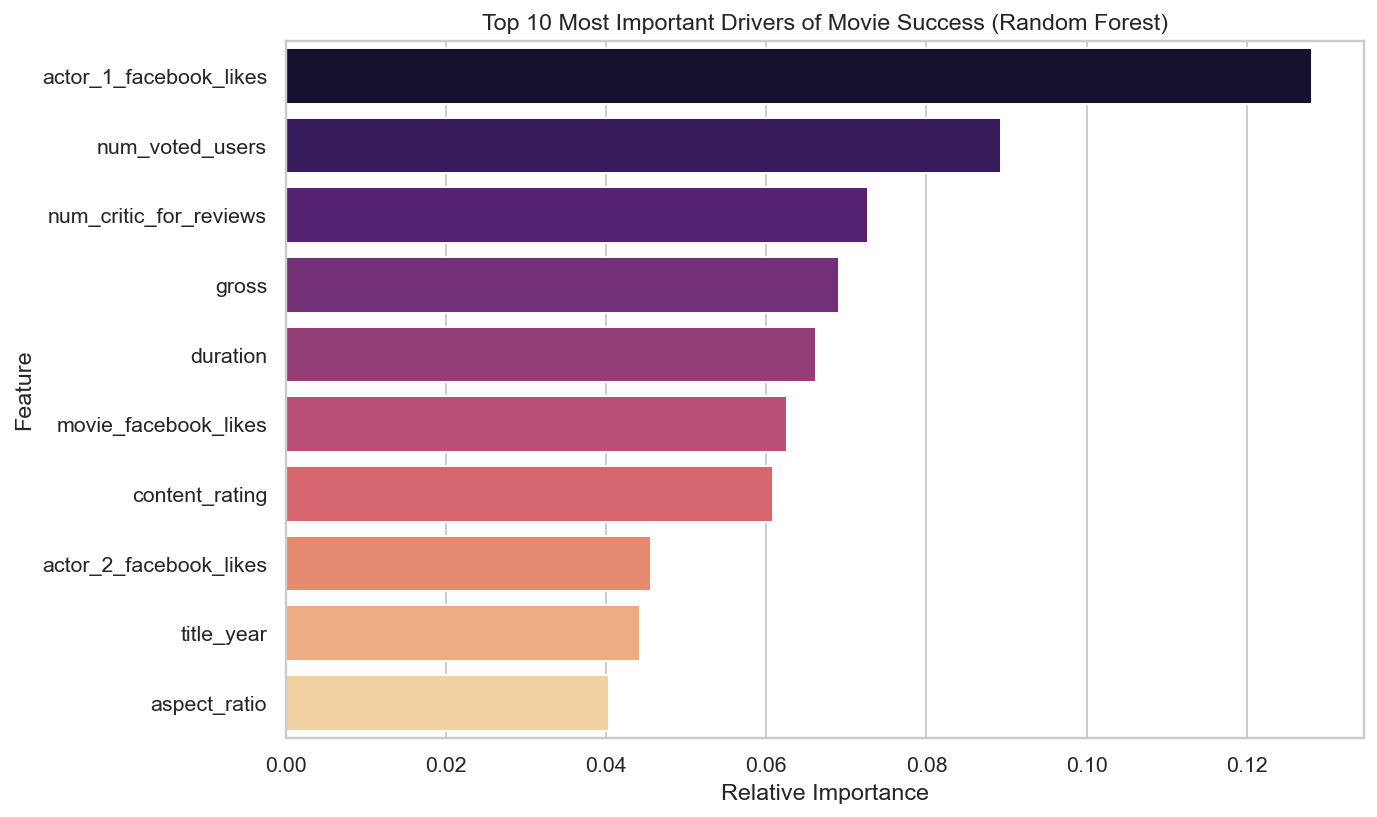

This chart shows what factors matter most for a movie's success.


In [83]:
print("Check which features are most important")
plt.figure(figsize=(10, 6))

# Extract importances from the Random Forest model
importances = rf_model.feature_importances_

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Get the top 10 most important features
top_n = 10
top_importances = importances[indices][:top_n]
# We need to get the feature names.
# X_train is a dataframe, but X_train_scaled is a numpy array. We can use X_train's columns.
# We dropped some columns due to collinearity, so we must use the columns of the data that was fed into the model.
# That data was scaled/encoded from X_train, so X_train.columns are valid.
top_features = X_train.columns[indices][:top_n]

# Plot
sns.barplot(x=top_importances, y=top_features, hue=top_features, palette='magma', legend=False)
plt.title('Top 10 Most Important Drivers of Movie Success (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
save_plot('12_Feature_Importance.png')
plt.show()

print("This chart shows what factors matter most for a movie's success.")

### Inferences: Feature Importance
This bar chart ranks the top features that the Random Forest model relies on.

In my run, engagement-related variables (such as votes, reviews, or social media likes) tend to appear near the top, while some budget- or cast-related features also play a strong role. This supports the idea that both audience interest and production scale matter when predicting whether a movie will end up as a Flop, Average, or Hit.

## 12. Saving the Models
Finally, I will save the best model along with the scalers and encoders. This way, the project can be used later to predict new movies without having to retrain everything.

In [84]:
print("Save the best model and preprocessors to use later")
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)

# Save the best model
model_filename = f"best_movie_model_{best_model_results['best_model_name'].replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, os.path.join(models_dir, model_filename))

# Save the scaler and encoder
joblib.dump(scaler, os.path.join(models_dir, 'standard_scaler.pkl'))
joblib.dump(encoder, os.path.join(models_dir, 'ordinal_encoder.pkl'))
joblib.dump(target_encoder, os.path.join(models_dir, 'target_label_encoder.pkl'))

print(f"Successfully saved {best_model_results['best_model_name']}, Scaler, Encoder, and Target Encoder to the '{models_dir}' directory.")

Save the best model and preprocessors to use later
Successfully saved xgboost, Scaler, Encoder, and Target Encoder to the './models' directory.


### Conclusion
- **Engagement is Key:** Metrics like reviews and Facebook likes seem to be strong predictors of a movie's success.

- **Handling Imbalance:** Balancing the dataset with SMOTE helped the model predict 'Flop' and 'Hit' more reliably.

- **Tree Models Work Well:** Random Forest and similar tree-based models worked well on this data and can handle outliers without a lot of extra preprocessing.